In [1]:
import apebench
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=2

/opt/anaconda3/envs/drift_bench_exponax/lib/python3.10/site-packages/trainax/_general_trainer.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=2


In [15]:
for model_key in results.keys():

    print(model_key)

    one_step_errors = []
    model_preds = []
    
    neural_stepper = results[model_key][0]
    
    model_rollout = np.array(results[model_key][1]["sample_rollout"][0])
    model_preds = [model_rollout[0]]
    gt_preds = [model_rollout[0]]

    

    for i in range(2000):
        model_preds.append(neural_stepper(model_preds[-1]))
        gt_preds.append(stepper(gt_preds[-1]))
        error = np.mean((model_preds[-1] - stepper(model_preds[-2]))**2).item()
        one_step_errors.append(error)
    
    results[model_key].append(one_step_errors)

one
sup;2
div;2


one
[1.1259031680310727e-06, 9.198711268254556e-07, 9.149079573944618e-07, 9.156912597063638e-07, 9.124885878009081e-07, 8.915895932659623e-07, 8.832487878862594e-07, 8.58618648180709e-07, 8.372346087526239e-07, 7.97413292730198e-07, 7.591201551804261e-07, 7.16288752755645e-07, 6.858828669464856e-07, 6.594150363525841e-07, 6.386363224919478e-07, 6.256788083192077e-07, 6.158925316412933e-07, 6.061592330297572e-07, 5.995821084070485e-07, 5.959705049463082e-07, 5.923304797761375e-07, 5.899570965084422e-07, 5.876226509826665e-07, 5.834747867083934e-07, 5.783896881439432e-07, 5.73752174659603e-07, 5.625360586236638e-07, 5.475864099935279e-07, 5.341822770787985e-07, 5.217490866016306e-07, 5.102589284433634e-07, 5.009143819734163e-07, 4.966275923834473e-07, 4.96507652769651e-07, 4.944636771142541e-07, 4.916098532703472e-07, 4.9411659119869e-07, 4.992591016161896e-07, 5.071478312856925e-07, 5.165616698832309e-07, 5.16587363108556e-07, 5.181726123737462e-07, 5.191270702198381e-07, 5.16041666287

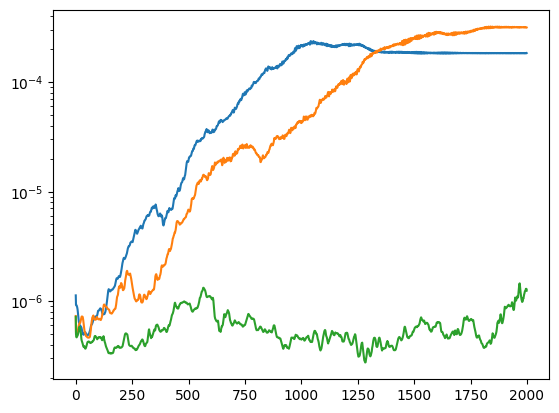

In [16]:
for model_key in results.keys():
    print(model_key)
    print(results[model_key][2])
    plt.plot(results[model_key][2])

plt.yscale('log')

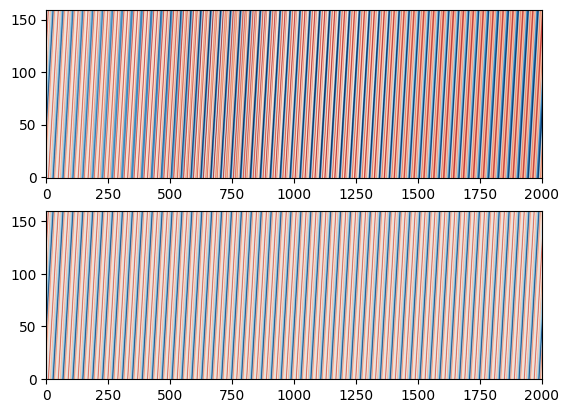

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(len(results.keys()), 1)

for i, model_key in enumerate(results.keys()):
    axes[i].imshow(np.array(model_preds)[:, 0].T,
                origin="lower",
        aspect="auto",
        vmin=-1,
        vmax=1,
        cmap="RdBu_r")

In [5]:
### 

from apebench import run_study, run_study_convenience

# Define train configurations
train_configs = ['one']# , 'sup;5', 'sup;8', 'div;8']
diffusion_alpha_configs = [-0.000025]
hyp_diffusion_alpha_configs = [-3.0e-9] #[-15.0, -7.5]
model_configs = ['Dil;2;32;2;relu', 'UNet;12;2;relu'] #['FNO;12;18;4;gelu',]
optim_configs = ["adam;80_000;warmup_cosine;0.0;1e-3;2_000",
                #"adam;10_000;warmup_cosine;0.0;1e-3;2_000",
                #"adam;20_000;warmup_cosine;0.0;1e-3;2_000",
                #"adam;40_000;warmup_cosine;0.0;1e-3;2_000",
                "adam;160_000;warmup_cosine;0.0;1e-3;2_000"]

configs = []
for train_config in train_configs:
    for diffusion_alpha in diffusion_alpha_configs:
        for hyp_diffusion_alpha in hyp_diffusion_alpha_configs:
            for optim_config in optim_configs:
                for model in model_configs:
                    config = {
                        'scenario': 'norm_ks',
                        'task': 'predict',
                        'net': model,
                        'train': train_config,
                        'start_seed': 0,
                        'num_seeds': 10,
                        'diffusion_alpha': diffusion_alpha,
                        'hyp_diffusion_alpha': hyp_diffusion_alpha,
                        'optim_config' : optim_config
                    }
                    configs.append(config)

# Run the study
run_study_convenience(configs=configs, base_path='results')


Considering
norm_ks__diffusion_alpha=-2.5e-05,hyp_diffusion_alpha=-3e-09,optim_config=adam;80_000;warmup_cosine;0.0;1e-3;2_000__predict__Dil;2;32;2;relu__one__0-9
Skipping, already trained ...

Considering
norm_ks__diffusion_alpha=-2.5e-05,hyp_diffusion_alpha=-3e-09,optim_config=adam;80_000;warmup_cosine;0.0;1e-3;2_000__predict__UNet;12;2;relu__one__0-9
Skipping, already trained ...

Considering
norm_ks__diffusion_alpha=-2.5e-05,hyp_diffusion_alpha=-3e-09,optim_config=adam;160_000;warmup_cosine;0.0;1e-3;2_000__predict__Dil;2;32;2;relu__one__0-9
Skipping, already trained ...

Considering
norm_ks__diffusion_alpha=-2.5e-05,hyp_diffusion_alpha=-3e-09,optim_config=adam;160_000;warmup_cosine;0.0;1e-3;2_000__predict__UNet;12;2;relu__one__0-9
Skipping, already trained ...



Melt and Concat metrics: 100%|██████████| 4/4 [00:24<00:00,  6.21s/it]


(      seed    scenario     task              net train  \
 0        0  1d_norm_ks  predict  Dil;2;32;2;relu   one   
 1        0  1d_norm_ks  predict  Dil;2;32;2;relu   one   
 2        0  1d_norm_ks  predict  Dil;2;32;2;relu   one   
 3        0  1d_norm_ks  predict  Dil;2;32;2;relu   one   
 4        0  1d_norm_ks  predict  Dil;2;32;2;relu   one   
 ...    ...         ...      ...              ...   ...   
 7995     9  1d_norm_ks  predict   UNet;12;2;relu   one   
 7996     9  1d_norm_ks  predict   UNet;12;2;relu   one   
 7997     9  1d_norm_ks  predict   UNet;12;2;relu   one   
 7998     9  1d_norm_ks  predict   UNet;12;2;relu   one   
 7999     9  1d_norm_ks  predict   UNet;12;2;relu   one   
 
                                         scenario_kwargs  time_step  \
 0     {'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...          1   
 1     {'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...          2   
 2     {'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...          3   
 3    

In [ ]:
from apebench import run_study, run_study_convenience

# Define train configurations
train_configs = ['one', 'sup;2', 'sup;5']#, 'sup;8', 'div;8']

configs = []
for train_config in train_configs:
    config = {
        'scenario': 'diff_disp',
        'task': 'predict',
        'net': 'UNet;12;2;relu',
        'train': train_config,
        'start_seed': 0,
        'num_seeds': 10,
        'test_temporal_horizon':200
    }
    configs.append(config)
    config = {
        'scenario': 'diff_disp',
        'task': 'predict',
        'net': 'FNO;12;18;4;gelu',
        'train': train_config,
        'start_seed': 0,
        'num_seeds': 10,
        'test_temporal_horizon':200
    }
    configs.append(config)

# Run the study
run_study_convenience(configs=configs, base_path='results')


Considering
diff_disp__test_temporal_horizon=200__predict__UNet;12;2;relu__one__0-9
Skipping, already trained ...

Considering
diff_disp__test_temporal_horizon=200__predict__FNO;12;18;4;gelu__one__0-9
Skipping, already trained ...

Considering
diff_disp__test_temporal_horizon=200__predict__UNet;12;2;relu__sup;2__0-9
Skipping, already trained ...

Considering
diff_disp__test_temporal_horizon=200__predict__FNO;12;18;4;gelu__sup;2__0-9
Skipping, already trained ...

Considering
diff_disp__test_temporal_horizon=200__predict__UNet;12;2;relu__sup;5__0-9
Skipping, already trained ...

Considering
diff_disp__test_temporal_horizon=200__predict__FNO;12;18;4;gelu__sup;5__0-9
Skipping, already trained ...



Melt and Concat metrics: 100%|██████████| 6/6 [00:07<00:00,  1.26s/it]


(       seed      scenario     task               net  train  \
 0         0  1d_diff_disp  predict    UNet;12;2;relu    one   
 1         0  1d_diff_disp  predict    UNet;12;2;relu    one   
 2         0  1d_diff_disp  predict    UNet;12;2;relu    one   
 3         0  1d_diff_disp  predict    UNet;12;2;relu    one   
 4         0  1d_diff_disp  predict    UNet;12;2;relu    one   
 ...     ...           ...      ...               ...    ...   
 11995     9  1d_diff_disp  predict  FNO;12;18;4;gelu  sup;5   
 11996     9  1d_diff_disp  predict  FNO;12;18;4;gelu  sup;5   
 11997     9  1d_diff_disp  predict  FNO;12;18;4;gelu  sup;5   
 11998     9  1d_diff_disp  predict  FNO;12;18;4;gelu  sup;5   
 11999     9  1d_diff_disp  predict  FNO;12;18;4;gelu  sup;5   
 
                       scenario_kwargs  time_step  mean_nRMSE  \
 0      {'test_temporal_horizon': 200}          1    0.008252   
 1      {'test_temporal_horizon': 200}          2    0.012488   
 2      {'test_temporal_horizon': 2

In [6]:
import pandas as pd
from matplotlib import pyplot as plt

metrics = pd.read_csv('results/metrics.csv')

In [7]:
metrics

,seed,scenario,task,net,train,scenario_kwargs,time_step,mean_nRMSE
0,0,1d_norm_ks,predict,Dil;2;32;2;relu,one,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",1,0.000395
1,0,1d_norm_ks,predict,Dil;2;32;2;relu,one,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",2,0.000722
2,0,1d_norm_ks,predict,Dil;2;32;2;relu,one,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",3,0.001008
3,0,1d_norm_ks,predict,Dil;2;32;2;relu,one,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",4,0.001269
4,0,1d_norm_ks,predict,Dil;2;32;2;relu,one,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",5,0.001512
...,...,...,...,...,...,...,...,...
7995,9,1d_norm_ks,predict,UNet;12;2;relu,one,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",196,0.732387
7996,9,1d_norm_ks,predict,UNet;12;2;relu,one,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",197,0.740203
7997,9,1d_norm_ks,predict,UNet;12;2;relu,one,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",198,0.747956
7998,9,1d_norm_ks,predict,UNet;12;2;relu,one,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",199,0.755653


In [8]:
average_mse_per_train_and_timestep = metrics.groupby(['net', 'train', 'time_step', 'scenario_kwargs'])['mean_nRMSE'].mean().reset_index()

In [9]:
average_mse_per_train_and_timestep

,net,train,time_step,scenario_kwargs,mean_nRMSE
0,Dil;2;32;2;relu,one,1,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",0.000314
1,Dil;2;32;2;relu,one,1,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",0.000419
2,Dil;2;32;2;relu,one,2,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",0.000548
3,Dil;2;32;2;relu,one,2,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",0.000755
4,Dil;2;32;2;relu,one,3,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",0.000755
...,...,...,...,...,...
795,UNet;12;2;relu,one,198,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",0.787345
796,UNet;12;2;relu,one,199,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",0.749137
797,UNet;12;2;relu,one,199,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",0.793928
798,UNet;12;2;relu,one,200,"{'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...",0.756879


<Axes: xlabel='time_step', ylabel='mean_nRMSE'>

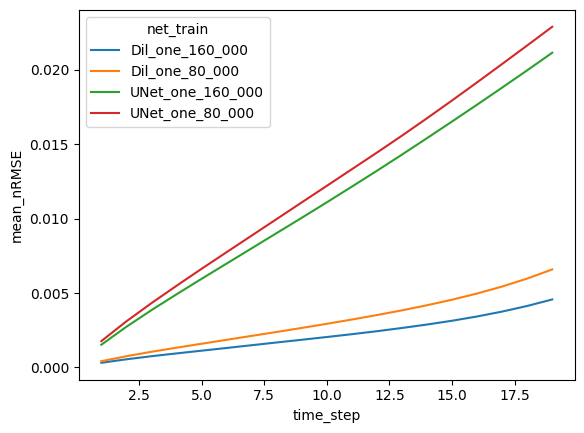

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

average_mse_per_train_and_timestep['net_train'] = (
    average_mse_per_train_and_timestep['net'].astype(str).apply(lambda x: x.split(';')[0]) + '_' +
    average_mse_per_train_and_timestep['train'].astype(str) + '_' +
    average_mse_per_train_and_timestep['scenario_kwargs'].astype(str).apply(lambda x:x.split(';')[1])
)
# Assuming your DataFrame is named 'average_mse_per_scenario_and_timestep'
sns.lineplot(
    data=average_mse_per_train_and_timestep[average_mse_per_train_and_timestep['time_step']<20],
    x='time_step',
    y='mean_nRMSE',
    hue='net_train',
)

In [11]:
average_mse_per_train_and_timestep['net_train'][0]

'Dil_one_160_000'

['Dil_one_160_000' 'Dil_one_80_000' 'UNet_one_160_000' 'UNet_one_80_000']
                 net train  time_step  \
0    Dil;2;32;2;relu   one          1   
1    Dil;2;32;2;relu   one          1   
400   UNet;12;2;relu   one          1   
401   UNet;12;2;relu   one          1   

                                       scenario_kwargs  mean_nRMSE  \
0    {'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...    0.000314   
1    {'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...    0.000419   
400  {'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...    0.001527   
401  {'diffusion_alpha': -2.5e-05, 'hyp_diffusion_a...    0.001772   

            net_train  
0     Dil_one_160_000  
1      Dil_one_80_000  
400  UNet_one_160_000  
401   UNet_one_80_000  
                 net train  time_step  \
38   Dil;2;32;2;relu   one         20   
39   Dil;2;32;2;relu   one         20   
438   UNet;12;2;relu   one         20   
439   UNet;12;2;relu   one         20   

                                       scen

/tmp/ipykernel_1071490/1475599923.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
/tmp/ipykernel_1071490/1475599923.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(tasks, rotation=45)
/tmp/ipykernel_1071490/1475599923.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.barplot(
/tmp/ipykernel_1071490/1475599923.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(tasks, rotation=45)
/tmp/ipykernel_1071490/1475599923.py:11: FutureWarning: 

Passing `palette` without assigning `h

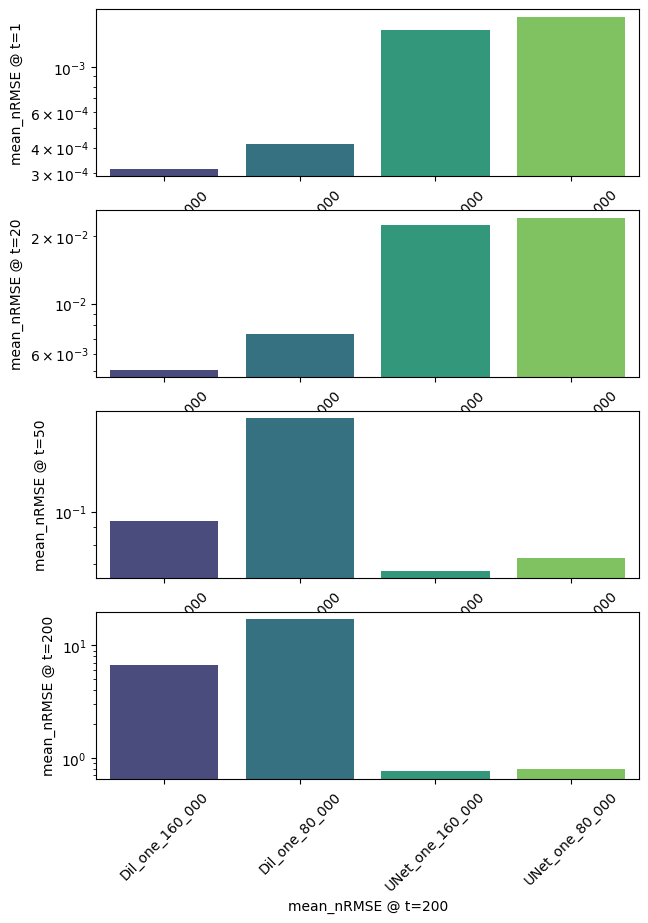

In [12]:
timesteps = [1, 20, 50, 200]
tasks = np.unique(average_mse_per_train_and_timestep['net_train'])
print(tasks)
fig, axes = plt.subplots(len(timesteps), figsize=(7,10))

for i, t in enumerate(timesteps):

    timestep_data = average_mse_per_train_and_timestep[average_mse_per_train_and_timestep['time_step'] == t]
    print(timestep_data)

    g = sns.barplot(
        data=timestep_data,
        x='net_train',
        y='mean_nRMSE',
        ax = axes[i],
        palette='viridis',
    )
    g.set_xticklabels(tasks, rotation=45)
    axes[i].set_ylabel(f'mean_nRMSE @ t={t}')
    axes[i].set_xlabel(f'mean_nRMSE @ t={t}')
    axes[i].set_yscale('log')